<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


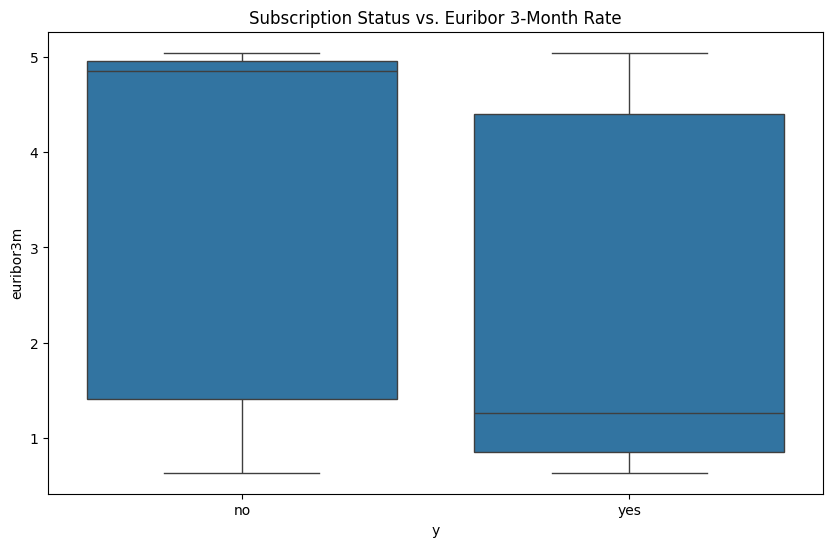

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
# Ensure the filename matches exactly what you uploaded
df = pd.read_csv('bank-additional-full.csv', sep=';')

print(df.info())
print(df['y'].value_counts(normalize=True))

print(f"Dataset loaded with {df.shape[0]} rows and {df.shape[1]} columns.")
display(df.head())

plt.figure(figsize=(10,6))
sns.boxplot(x='y', y='euribor3m', data=df)
plt.title('Subscription Status vs. Euribor 3-Month Rate')
plt.show()

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Drop 'duration' per documentation warning
df_cleaned = df.drop(columns=['duration'])

# Convert target 'y' to binary (1 for yes, 0 for no) [cite: 25]
df_cleaned['y'] = df_cleaned['y'].apply(lambda x: 1 if x == 'yes' else 0)

# One-hot encoding for categorical variables [cite: 16, 17, 18]
df_final = pd.get_dummies(df_cleaned, drop_first=True)

# Split into Features (X) and Target (y) [cite: 13]
X = df_final.drop('y', axis=1)
y = df_final['y']

# 80/20 Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

              precision    recall  f1-score   support

           0       0.91      0.97      0.94      7303
           1       0.54      0.29      0.38       935

    accuracy                           0.89      8238
   macro avg       0.73      0.63      0.66      8238
weighted avg       0.87      0.89      0.88      8238



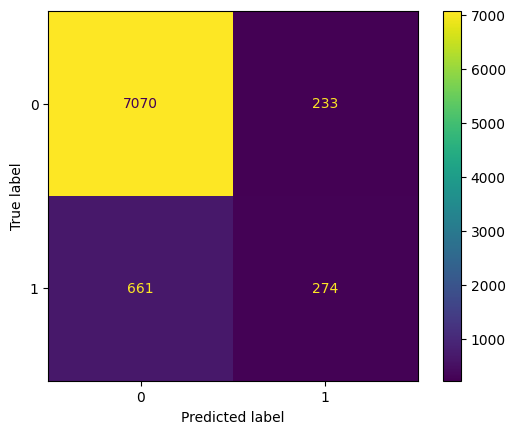

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = model.predict(X_test_scaled)

# Evaluate performance
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
ConfusionMatrixDisplay.from_estimator(model, X_test_scaled, y_test)
plt.show()

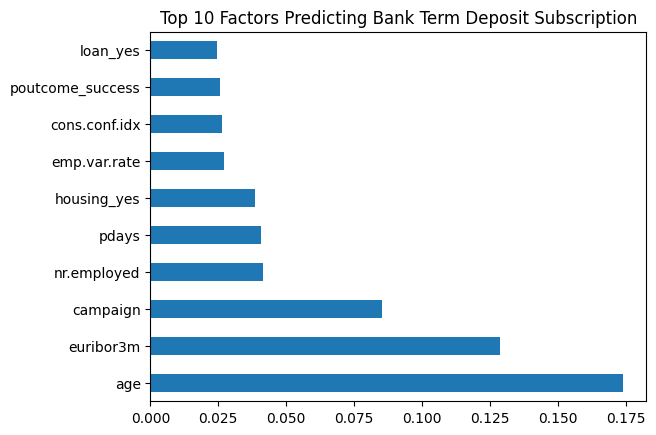

In [13]:
# Extract and plot feature importance
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 Factors Predicting Bank Term Deposit Subscription')
plt.show()